# Notebook 1: Environment Setup & DeepFluoro Data Loading

**Pipeline**: FastDRR-style 2D/3D Registration for Hip Fluoroscopy  
**Paper reference**: Freund et al., 2004 — *Direction Dependent Projection Fields for Fast DRR Generation*  
**Modern stack**: DiffDRR (Gopalakrishnan & Golland) + DeepFluoro dataset (Grupp et al., 2020)

## Overview
This notebook:
1. Installs all dependencies
2. Downloads and loads the DeepFluoro HDF5 dataset
3. Visualizes the CT volume and fluoroscopy images
4. Inspects ground truth camera poses

---

## 1.1 Install Dependencies

Run this once. On Mac (Apple Silicon), PyTorch uses MPS (Metal Performance Shaders) for GPU acceleration.

In [1]:
# Install core packages
# NOTE: On Apple Silicon Macs, PyTorch MPS backend provides hardware acceleration

import subprocess, sys

packages = [
    'diffdrr',
    'diffdrrdata',    # contains DeepFluoro + Ljubljana dataloaders
    'torch torchvision',
    'matplotlib seaborn',
    'numpy scipy',
    'h5py',
    'ipywidgets',
    'tqdm',
    'kornia',         # image similarity metrics (NCC, NMI)
    'einops',
    'pyvista',        # 3D volume visualization
    'torchio',        # medical image transforms
]

for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet'] + pkg.split())

print('\n✅ All packages installed!')

Installing diffdrr...
Installing diffdrrdata...
Installing torch torchvision...
Installing matplotlib seaborn...
Installing numpy scipy...
Installing h5py...
Installing ipywidgets...
Installing tqdm...
Installing kornia...
Installing einops...
Installing pyvista...
Installing torchio...

✅ All packages installed!


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- Device selection: MPS (Apple Silicon) > CUDA > CPU ---
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print('🍎 Using Apple MPS (Metal) GPU acceleration')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'🚀 Using CUDA GPU: {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
    print('💻 Using CPU (no GPU found — DRR will be slower but works fine)')

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')

🍎 Using Apple MPS (Metal) GPU acceleration
PyTorch version: 2.8.0
Device: mps


## 1.2 Load the DeepFluoro Dataset

The DeepFluoro dataset contains:
- **6 cadaveric specimens** with paired CT + fluoroscopy
- CT volumes of the pelvis/hip
- Real C-arm fluoroscopy images with **ground truth camera poses** (from offline registration)
- Anatomical landmark annotations (femoral head, ASIS, etc.)

The `diffdrrdata` package automatically downloads the 4x downsampled version (~165 MB) on first use.

In [ ]:
import shutil, os
from pathlib import Path

# Create the expected directory
data_dir = Path("~/user/diffdrr_data").expanduser()
data_dir.mkdir(parents=True, exist_ok=True)

##create output dir
os.makedirs('../outputs', exist_ok=True)

# Point this to wherever your .h5 file actually is
your_h5 = Path("/Users/zoecrookshank/Desktop/MEng - UofT/JEB1433/ipcai_2020_full_res_data/ipcai_2020_full_res_data.h5")

# Copy (or use .rename() to move instead)
shutil.copy(your_h5, data_dir / "ipcai_2020_full_res_data.h5")
print("✅ Done!")


✅ Done!


In [7]:
from diffdrrdata.deepfluoro import DeepFluoroDataset, Transforms
from pathlib import Path
##force directory
Path("~/user/diffdrr_data").expanduser().mkdir(parents=True, exist_ok=True)
print("✅ Created data directory")

# Load subject 1 (specimens 1–6 available)
# First run will download the HDF5 file (~165 MB) automatically
SUBJECT_ID = 1  # Change to 1-6 to explore different specimens
SUBSAMPLE   = 4  # Downsample factor: higher = faster but lower resolution

print(f'Loading DeepFluoro subject {SUBJECT_ID}...')
deepfluoro = DeepFluoroDataset(id_number=SUBJECT_ID)
print(f'✅ Loaded subject {SUBJECT_ID}')
print(f'   Number of fluoroscopy frames: {len(deepfluoro)}')
print(f'   CT volume shape:  {deepfluoro.subject.volume.shape}')
print(f'   CT voxel spacing: {deepfluoro.subject.spacing} mm')
print(f'   Fluoroscopy height: {deepfluoro.height} px')
print(f'   Focal length (SDD): {deepfluoro.focal_len:.1f} mm')
print(f'   Pixel spacing (delx): {deepfluoro.delx:.3f} mm')

✅ Created data directory
Loading DeepFluoro subject 1...
✅ Loaded subject 1
   Number of fluoroscopy frames: 111
   CT volume shape:  (1, 398, 197, 341)
   CT voxel spacing: (1.0, 1.0, 1.0) mm
   Fluoroscopy height: 1436 px
   Focal length (SDD): 1020.0 mm
   Pixel spacing (delx): 0.194 mm


## 1.3 Inspect the CT Volume

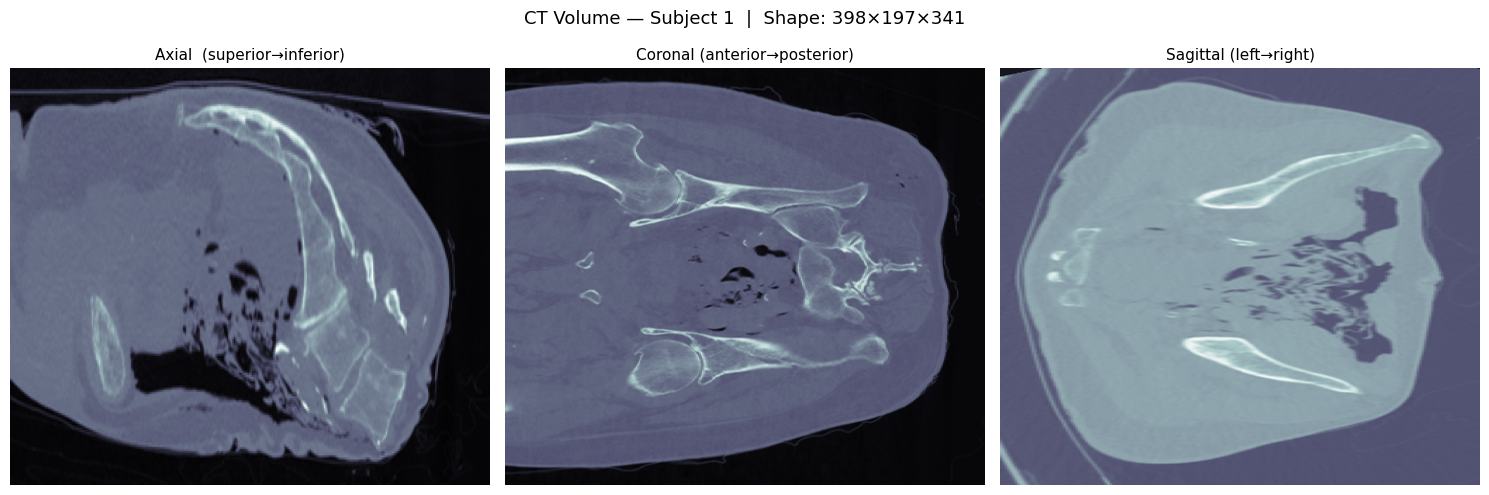

In [10]:
# Visualize orthogonal CT slices
# .data gives the raw tensor (C, D, H, W), then squeeze removes the channel dim
volume = deepfluoro.subject.volume.data.squeeze().numpy()  # (D, H, W)
D, H, W = volume.shape

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'CT Volume — Subject {SUBJECT_ID}  |  Shape: {D}×{H}×{W}', fontsize=13)

slices = [
    (volume[D//2, :, :], 'Axial  (superior→inferior)'),
    (volume[:, H//2, :], 'Coronal (anterior→posterior)'),
    (volume[:, :, W//2], 'Sagittal (left→right)'),
]

for ax, (sl, title) in zip(axes, slices):
    ax.imshow(sl, cmap='bone', aspect='auto')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 1.4 Inspect the Fluoroscopy Images & Ground Truth Poses

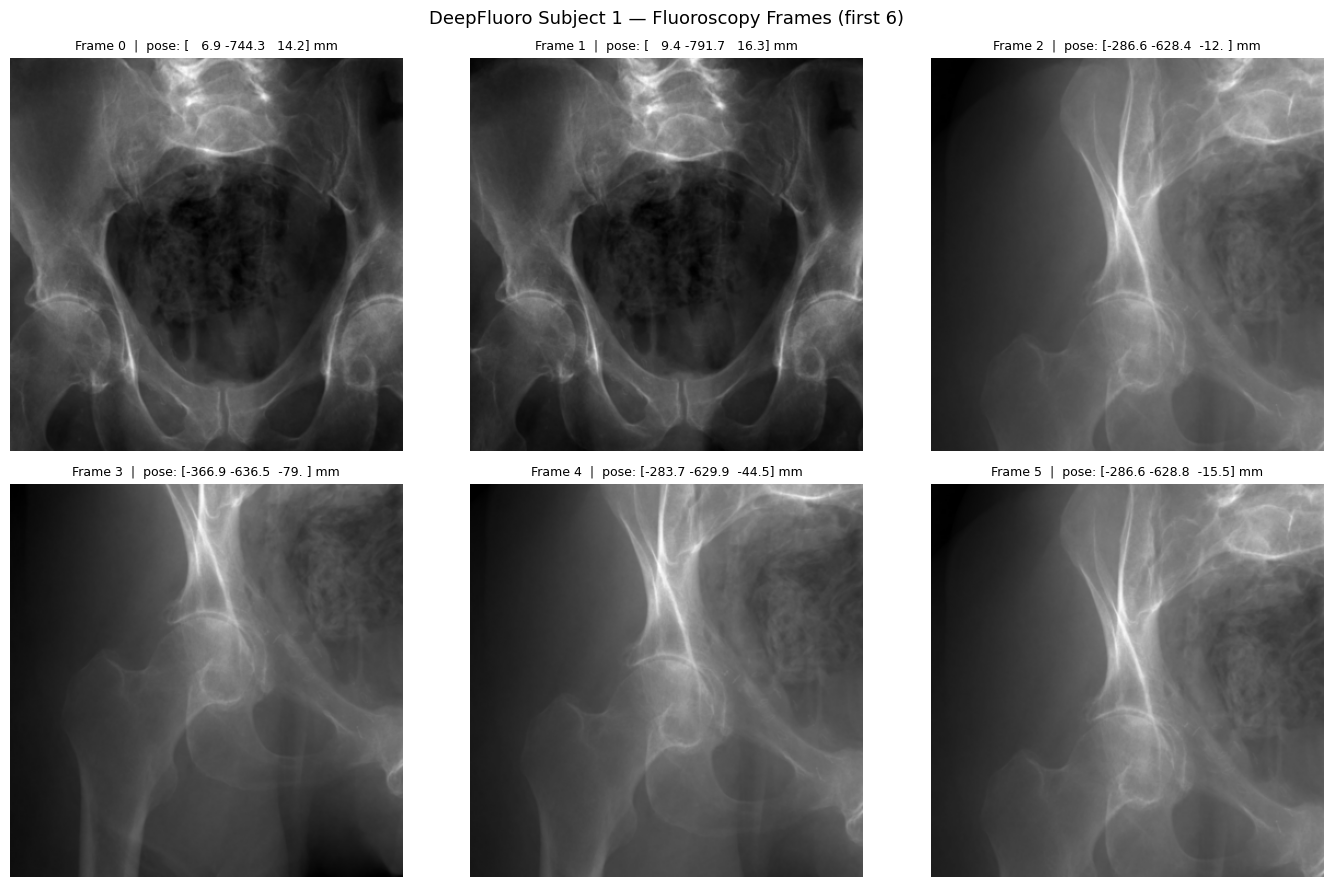

In [20]:
transform = Transforms(deepfluoro.height // SUBSAMPLE)

# Show first 6 fluoroscopy frames
n_show = min(6, len(deepfluoro))
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle(f'DeepFluoro Subject {SUBJECT_ID} — Fluoroscopy Frames (first {n_show})', fontsize=13)

for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis('off')
        continue
    
    gt_img, pose = deepfluoro[i]
    gt_img = transform(gt_img)
    
    ax.imshow(gt_img.squeeze().numpy(), cmap='gray')
    ax.set_title(f'Frame {i}  |  pose: {pose.matrix[0,:3,3].numpy().round(1)} mm', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [16]:
# Print ground truth pose for frame 0
gt_img, gt_pose = deepfluoro[0]

print('Ground truth pose (SE3 transformation matrix):')
print(gt_pose.matrix.squeeze().numpy().round(4))
print()
print('Translation (x, y, z) in mm:', gt_pose.matrix[0, :3, 3].numpy().round(2))
print()
print('This 4×4 SE3 matrix encodes the camera pose in 3D space.')
print('DiffDRR uses this to cast rays from the correct source position through the CT volume.')

Ground truth pose (SE3 transformation matrix):
[[ 9.974000e-01  6.000000e-04 -7.220000e-02  6.945400e+00]
 [ 2.100000e-03  9.993000e-01  3.630000e-02 -7.443022e+02]
 [ 7.210000e-02 -3.630000e-02  9.967000e-01  1.421940e+01]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  1.000000e+00]]

Translation (x, y, z) in mm: [   6.95 -744.3    14.22]

This 4×4 SE3 matrix encodes the camera pose in 3D space.
DiffDRR uses this to cast rays from the correct source position through the CT volume.


## 1.5 Save Dataset Config for Other Notebooks

In [17]:
import json

config = {
    'subject_id': SUBJECT_ID,
    'subsample': SUBSAMPLE,
    'n_frames': len(deepfluoro),
    'ct_shape': list(deepfluoro.subject.volume.shape),
    'focal_len': float(deepfluoro.focal_len),
    'height': int(deepfluoro.height),
    'delx': float(deepfluoro.delx),
    'x0': float(deepfluoro.x0),
    'y0': float(deepfluoro.y0),
    'device': str(device),
}

with open('../outputs/dataset_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print('✅ Config saved to outputs/dataset_config.json')
print(json.dumps(config, indent=2))

✅ Config saved to outputs/dataset_config.json
{
  "subject_id": 1,
  "subsample": 4,
  "n_frames": 111,
  "ct_shape": [
    1,
    398,
    197,
    341
  ],
  "focal_len": 1020.0,
  "height": 1436,
  "delx": 0.1940000057220459,
  "x0": -0.09700000286102295,
  "y0": -0.09700000286102295,
  "device": "mps"
}


---
## Summary

| Item | Value |
|------|-------|
| Dataset | DeepFluoro (Grupp et al., 2020) |
| Specimens | 6 cadaveric pelvis CT + fluoroscopy |
| CT format | 3D Hounsfield volume (via TorchIO) |
| Fluoroscopy | Real C-arm images with GT poses |
| DRR renderer | DiffDRR (Gopalakrishnan & Golland, 2022) |
| Key insight | Same as Freund 2004: DRR as pre-computed ray integrals, but now *differentiable* |

**Next**: Notebook 02 — DRR Generation with DiffDRR